# Notebook 2 Transformation of Data  and Feature Selection

## Project Overview 

> **Phase 1 — Notebook 2 of 3** | This notebook is part of a two-phase credit risk 
> model development and validation project. Phase 1 develops and validates a model 
> on 614 observations. Phase 2 scales the methodology to 45,000 observations.

This project analyzes a dataset of 614 loan applications to understand the factors influencing loan approval and to develop a framework for assessing credit risk. The analysis includes exploratory data analysis, feature engineering, and predictive modeling using Logistic Regression and XGBoost.

The project is divided into three parts:

1. Data Quality and Cleaning  
2. Feature Engineering and Risk Analysis  
3. Credit Risk Modeling  

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/burak3ergun/loan-data-set/data and contains demographic and financial information for 614 loan applicants.

This dataset is used for methodological demonstration purposes. In a production model, variables such as Gender would be excluded on fairness and regulatory grounds consistent with GDPR Article 22 and EBA guidelines on non-discriminatory credit models. This exclusion is implemented in Phase 2.

### Approach

In this part of the project, the focus is on transforming data and evaluating key features in estimating the approval of a loan.

The main objectives of this notebook are:

1. **Splitting Data**  
   - The dataset is split into training and testing sets to ensure proper model evaluation and avoid data leakage.
   
2. **Data Preparation and Transformation**  
   - Ensure numeric and categorical variables are uniform and suitable for modeling.  
   - Derive new features, such as "Total_Income", "DTI", "Dept_Ratio", and "Has_Coapplicant", to better capture predictive signals.
   - Apply transformations such as winsorization and logarithmic scaling to reduce skewness and handle extreme values. All transformation limits (winsorization bounds) are calculated from training data only and applied to both train and test sets. This prevents data leakage and ensures the test set remains a true holdout.  

3. **Feature Selection and Model Preparation**  
   - Identify redundant or non-informative features.  
   - Evaluate predictive power of variables using Logistic Regression and XGBoost.  
   - Decide which features should be retained for the final modeling stage.

This notebook builds on the cleaned dataset from Notebook 1 and prepares it for **predictive modeling and risk evaluation** in the subsequent notebook. The steps are designed to ensure that features are informative, interpretable, and robust for Logistic Regression and tree-based models like XGBoost.


### Business Context

Financial institutions use credit risk modeling to assess the likelihood of borrowers repaying loans. Poor lending decisions increase default risk and financial losses. By analyzing historical loan application data, predictive models identify patterns in borrower characteristics and financial indicators that influence loan approval.

In this project, the objective is to explore borrower characteristics and financial indicators that influence loan approval decisions and to develop a model that estimates the likelihood of loan approval.

### References

This project was developed with guidance from a tutorial series by Muhammad Faizin Zen on Medium, which explains the process of building a credit scoring model step-by-step. The articles were used as references for understanding typical preprocessing steps and modeling approaches used in credit risk analysis.

To better understand credit risk datasets and typical preprocessing approaches used in credit scoring, the following resources were used:

Articles on Medium by Muhammad Faizin Zen:

- Building a Credit Score Model: Feature Engineering and Encoding (2025)  
- Building a Credit Score Model: Feature Selection (2025)

Example on Kaggle by Louis Deconinck
- Credit Risk Modelling: Probability of Default (2023)

### Table of Contents

1. Project Overview  
2. Packages Used  
3. Downloading
   - 3.1 Splitting Data to Train and Test Set
   - 3.2 Transforming Data 
        - 3.2.1 Feature Engineering and Uniforming Data
        - 3.2.2 Transforming Numeric Data

4. Feature Selection 
   - 4.1 Logistic Regression   
   - 4.2 XGBoost

5. Downloading Train and Test Data 

6. Conclusions

# 2. Packages used

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
from scipy.stats import pointbiserialr, chi2_contingency
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import xgboost as xgb
from xgboost import plot_importance

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Downloading and Inspecting Data

In [2]:
df = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\cleaned_data\clean_data.csv")
df_xgb = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\raw_data\loan_data_set.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Loan_Amount_Term_grouped
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y,360.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N,360.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y,360.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y,360.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y,360.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loan_ID                   614 non-null    object 
 1   Gender                    614 non-null    object 
 2   Married                   614 non-null    object 
 3   Dependents                614 non-null    object 
 4   Education                 614 non-null    object 
 5   Self_Employed             614 non-null    object 
 6   Applicant_Income          614 non-null    float64
 7   Coapplicant_Income        614 non-null    float64
 8   Loan_Amount               614 non-null    float64
 9   Loan_Amount_Term          614 non-null    float64
 10  Credit_History            614 non-null    float64
 11  Property_Area             614 non-null    object 
 12  Loan_Status               614 non-null    object 
 13  Loan_Amount_Term_grouped  614 non-null    object 
dtypes: float64

## 3.1 Splitting data to train and test data

The dataset will be split into training (80%) and test (20%) sets.

Before splitting, the categorical feature Loan_ID will be dropped, as it is an identifier (a running number) and does not carry predictive information. Removing this column also helps prevent data leakage, ensuring the model does not learn from irrelevant identifiers.

I'll be testing two models Logistic regression and XGBoost. XGBoost applied to raw data to evaluate native missing value handling, logistic regression applied to processed data for IRB interpretability.

In [4]:
#dropping Loan_ID
df = df.drop(["Loan_ID"], axis=1)
df["Dependents"] = df["Dependents"].replace("3+", 3).astype("uint8")

# Target variable is Loan_Status, so model predicts if a loan is approved/rejected
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"].map({"Y":1,"N":0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Amount_Term_grouped
154,Male,No,0,Graduate,No,3254.0,0.0,50.0,360.0,1.0,Urban,360.0
239,Male,Yes,1,Graduate,No,3315.0,0.0,96.0,360.0,1.0,Semiurban,360.0
448,Male,Yes,2,Graduate,No,3340.0,1710.0,150.0,360.0,0.0,Rural,360.0
471,Male,Yes,1,Not Graduate,No,2653.0,1500.0,113.0,180.0,0.0,Rural,180.0
273,Male,Yes,0,Graduate,No,2620.0,2223.0,150.0,360.0,1.0,Semiurban,360.0


### 3.2.1 Transforming data and Feature Engineering

In the next function, I will perform two main tasks:

**A. Uniforming Data Types and Cleaning**

To ensure consistent and model-ready data, the following steps will be applied:

- Drop redundant columns:

  - Loan_Amount_Term will be removed because Loan_Amount_Term_grouped captures the same information while handling outliers.

-  One-hot encoding:

   - Gender, Married, Education, Self_Employed, and Credit_History will be converted to binary (0/1) for easier analysis.

- Label encoding:

  - Property_Area and Loan_Amount_Term_grouped will be label encoded.

- Simplifying categories:

  - Dependents values of 3+ will be converted to 3 for uniformity.

- Numeric transformations:

  - All income- and loan-related columns will be transformed into comparable forms using previously applied capping and log-transformations.

**B. Feature Creation**

To improve predictive power and capture household-level financial context, the following features will be added, based on insights from Muhammad Faizin Zen’s guide on credit scoring:

- Total_Income:

  - The sum of applicant and coapplicant income, representing household earnings.

- DTI (Debt-to-Income ratio):

  - Represents the ratio of loan amount to total household income, highlighting repayment burden.

- Debt_Ratio:

  - Represents the ratio of loan amount to applicant income only, capturing individual financial pressure.

- Has_Coapplicant:

  - A binary indicator showing whether a coapplicant exists, which helps handle skew in coapplicant income and improves model interpretability.

This function ensures that all variables are numeric or encoded consistently, and that engineered features provide meaningful financial insights, setting the stage for modeling.

In [6]:
datasets = ["X_train", "X_test"]

remove_cols = ["Dependents", "Property_Area","Loan_Amount_Term_grouped"]

def uniforming_data(data):
    
    data['Total_Income'] = data['Applicant_Income'] + data['Coapplicant_Income']
    data["DTI"] = data["Total_Income"]/data["Loan_Amount"]
    data["Dept_Ratio"] = data["Applicant_Income"]/data["Loan_Amount"]
    
    data = data.drop(["Loan_Amount_Term"], axis=1)
    
    data["Credit_History"] = data["Credit_History"].astype("object")
    
    data['Dependents'] = data['Dependents'].replace('3+', 3).astype("uint8")

    cat_cols = data.select_dtypes(include="object").columns
    cat_cols_binary =[]
    
    for i in cat_cols:
        if i not in remove_cols:
            cat_cols_binary.append(i)
    
    # Encode categorical features
    data = pd.get_dummies(data, columns=cat_cols_binary, drop_first=True)
    data = pd.get_dummies(data, columns=["Property_Area", "Loan_Amount_Term_grouped"])
    data["Has_Coapplicant"] = ((data["Coapplicant_Income"] > 0)).astype("uint8")
    
    return data

for name in datasets:
    globals()[name] = uniforming_data(globals()[name])

In [7]:
X_train

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Total_Income,DTI,Dept_Ratio,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Credit_History_1.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Amount_Term_grouped_180.0,Loan_Amount_Term_grouped_360.0,Loan_Amount_Term_grouped_Other,Has_Coapplicant
154,0,3254.0,0.0,50.0,3254.0,65.080000,65.080000,1,0,0,0,1,0,0,1,0,1,0,0
239,1,3315.0,0.0,96.0,3315.0,34.531250,34.531250,1,1,0,0,1,0,1,0,0,1,0,0
448,2,3340.0,1710.0,150.0,5050.0,33.666667,22.266667,1,1,0,0,0,1,0,0,0,1,0,1
471,1,2653.0,1500.0,113.0,4153.0,36.752212,23.477876,1,1,1,0,0,1,0,0,1,0,0,1
273,0,2620.0,2223.0,150.0,4843.0,32.286667,17.466667,1,1,0,0,1,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,0,2971.0,2791.0,144.0,5762.0,40.013889,20.631944,1,0,0,0,1,0,1,0,0,1,0,1
349,0,2625.0,6250.0,187.0,8875.0,47.459893,14.037433,1,1,0,0,1,1,0,0,0,1,0,1
26,0,2799.0,2253.0,122.0,5052.0,41.409836,22.942623,1,1,0,0,1,0,1,0,0,1,0,1
96,0,2484.0,2302.0,137.0,4786.0,34.934307,18.131387,0,1,0,0,1,0,1,0,0,1,0,1


### 3.2.2 Transformation of skewed values

In the previous notebook, we observed how log-transforming the data reduced skewness, which is expected for income- and loan-related features.

To further handle extreme values, Winsorization was applied, capping data at the 1st and 99th percentiles, except for Coapplicant_Income. For this feature, capping was applied only at the 99th percentile, since it contains zeros for applicants without a coapplicant.

After this step, some outliers became more apparent, which will now be addressed for numeric data.

This preprocessing is applied only to the data used for logistic regression, as tree-based models like XGBoost are generally robust to skewness and outliers.

In [8]:
numeric_col = X_train.select_dtypes(include="float64").columns

# Calculate limits from training data only
limits = {}
for i in numeric_col:
    if i == "Coapplicant_Income":
        limits[i] = {"upper": X_train[i].quantile(0.99)}
    else:
        limits[i] = {"lower": X_train[i].quantile(0.01), 
                     "upper": X_train[i].quantile(0.99)}

def data_transformation(data, limits):
    for i in numeric_col:
        if i == "Coapplicant_Income":
            data[f"{i}_log"] = np.log1p(
                np.where(data[i] > limits[i]["upper"], limits[i]["upper"], data[i])
            )
        else:
            data[f"{i}_log"] = np.log1p(
                np.clip(data[i], limits[i]["lower"], limits[i]["upper"])
            )
    return data

X_train = data_transformation(X_train, limits)
X_test = data_transformation(X_test, limits)

In [9]:
numeric_cols = X_train.select_dtypes(include="float64").columns 

#Calculating skewness of data
skew = X_train[numeric_cols].skew()
skew

Applicant_Income          6.545918
Coapplicant_Income        7.605759
Loan_Amount               2.791354
Total_Income              5.779082
DTI                       4.314345
Dept_Ratio                4.436805
Applicant_Income_log      0.942426
Coapplicant_Income_log   -0.144892
Loan_Amount_log           0.113790
Total_Income_log          1.003135
DTI_log                   1.656322
Dept_Ratio_log            0.741442
dtype: float64

### Section 3. Conclusion

Key observations from this section:

- The dataset contains a significant amount of missing data, which requires appropriate handling.

- For income and loan-related features, the maximum values are well above the 75th percentile, indicating extreme values that need attention.

The original features related to loan amounts and applicant/coapplicant income will be retained in the dataset until the modeling stage. This ensures that the model can properly evaluate and interpret the risk associated with each applicant, while also allowing transformed or engineered versions of these features to be used as inputs for modeling.

# 4. Feature selection

## 4.1 For Logistic Regression

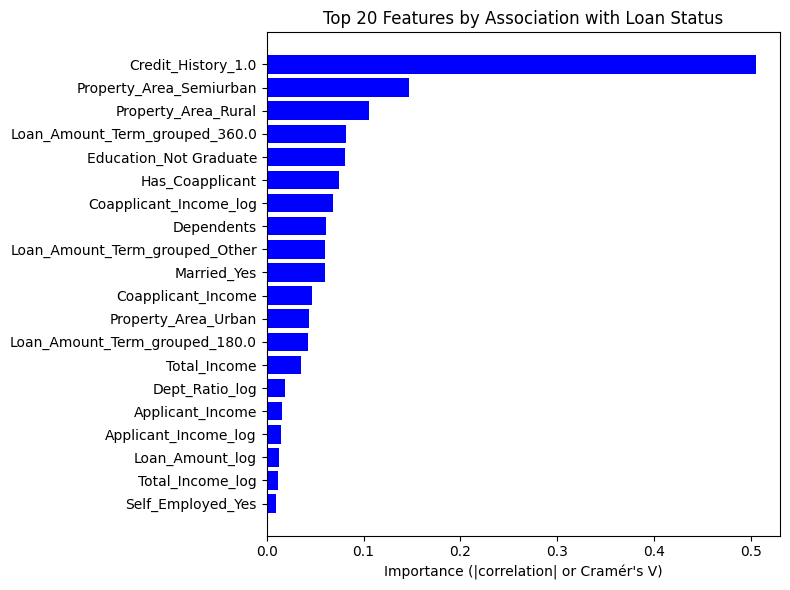

                       Feature        Type  importance
            Credit_History_1.0 Categorical       0.505
       Property_Area_Semiurban Categorical       0.147
           Property_Area_Rural Categorical       0.106
Loan_Amount_Term_grouped_360.0 Categorical       0.082
        Education_Not Graduate Categorical       0.081
               Has_Coapplicant Categorical       0.075
        Coapplicant_Income_log     Numeric       0.068
                    Dependents Categorical       0.061
Loan_Amount_Term_grouped_Other Categorical       0.060
                   Married_Yes Categorical       0.060
            Coapplicant_Income     Numeric       0.047
           Property_Area_Urban Categorical       0.044
Loan_Amount_Term_grouped_180.0 Categorical       0.043
                  Total_Income     Numeric       0.035
                Dept_Ratio_log     Numeric       0.019
              Applicant_Income     Numeric       0.016
          Applicant_Income_log     Numeric       0.015
          

In [10]:
# Cramér's V function
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = len(x)
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k))

# Combine X_train and y_train for analysis
df_train = X_train.copy()
df_train["Loan_Status"] = y_train

numeric_cols = df_train.select_dtypes(include="float64").columns.drop("Loan_Status", errors="ignore")
categorical_cols = df_train.select_dtypes(exclude="float64").columns.drop("Loan_Status", errors="ignore")

# Store results
feature_summary = []

# Numeric features: absolute point biserial correlation
for col in numeric_cols:
    r, p = pointbiserialr(df_train["Loan_Status"], df_train[col])
    feature_summary.append({
        "Feature": col,
        "Type": "Numeric",
        "importance": round(abs(r), 3)
    })

# Categorical features: Cramér's V
for col in categorical_cols:
    v = cramers_v(df_train[col], df_train["Loan_Status"])
    feature_summary.append({
        "Feature": col,
        "Type": "Categorical",
        "importance": round(v, 3)
    })

feature_eval = pd.DataFrame(feature_summary)
top_features = feature_eval.sort_values(by="importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"][::-1], top_features["importance"][::-1], color="blue")
plt.xlabel("Importance (|correlation| or Cramér's V)")
plt.title("Top 20 Features by Association with Loan Status")
plt.tight_layout()
plt.show()

# Print full table
print(feature_eval.sort_values(by="importance", ascending=False).to_string(index=False))

Credit_History emerges as the strongest predictor. This is consistent with the bivariate analysis in Notebook 1. Has_Coapplicant shows meaningful association, validating the feature engineering decision. Property_Area_Semiurban shows notable location-based signal. Education, Self_Employed, and Gender show weak individual associations but are retained due to the small dataset means weak predictors may contribute through interactions.

## 4.2 XGBoost

XGBoost is a flexible, tree-based model capable of handling complex data structures that may challenge linear models like Logistic Regression. In particular, it is robust to outliers and can handle missing values internally during tree construction. Additionally, XGBoost provides feature importance measures, allowing us to identify which variables contribute most to predictions.

For this experiment, the model will be applied to the original dataset without the feature engineering steps used in previous sections. This allows us to evaluate how well XGBoost performs on relatively raw data.

Categorical variables will be one-hot encoded to convert them into a numerical format suitable for the model. No additional feature engineering will be applied at this stage.

After training, the feature importance output will be analyzed to understand which variables the model considers most influential. This provides insight into the predictive power of the original features and highlights differences between models that require careful preprocessing (Logistic Regression) and models like XGBoost that can automatically adapt to more complex and unprocessed input data

In [11]:
df_xgb = df_xgb.drop("Loan_ID", axis=1)

X = df_xgb.drop("Loan_Status", axis=1)
y = df_xgb["Loan_Status"].map({"Y":1,"N":0})
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

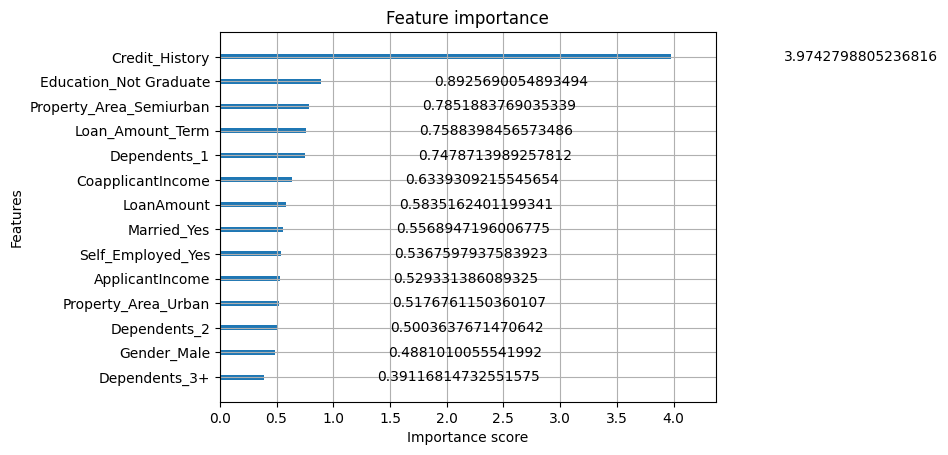

In [12]:
model = xgb.XGBClassifier()
model.fit(X_train_xgb, y_train_xgb)

# Feature importance
plot_importance(model, importance_type="gain")
plt.show()

### Section 4. Conclusion

Credit_History emerged as the strongest predictor of loan approval, reflecting the critical role of a borrower’s repayment record in lending decisions. Certain property areas, such as Property_Area_Semiurban and Property_Area_Rural, also showed predictive value, highlighting location-based differences in approval rates. The Has_Coapplicant feature was important in the Logistic Regression model, indicating that the presence of a co-applicant meaningfully impacts the probability of loan approval. Similarly, other features like Education and Loan_Amount_Term were identified as relevant in the XGBoost model, aligning with the bivariate analysis conducted in Notebook 1.

Despite some features having weaker individual associations with the target, no features are removed for several reasons:

- Preserve all available information: The dataset is relatively small, so removing features could result in the loss of potentially useful signals.  
- Support feature interactions: Variables that appear weak individually may contribute predictive power when combined with others, particularly in models like Logistic Regression or XGBoost.  
- Maintain flexibility for modeling: Keeping both raw and transformed/derived features (e.g., ApplicantIncome, Total_Income, LoanAmount_log) provides multiple representations of the same underlying information, which can improve model stability and interpretability.

In summary, retaining all features ensures that the model leverages both strong predictors and supporting signals while allowing later feature selection or regularization to identify the most informative subset for final predictions. This approach balances predictive power, interpretability, and flexibility in modeling.

# 5. Downloading data

In [13]:
X_train.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\X_train.csv", 
               index=False)
X_test.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\X_test.csv", 
              index=False)
y_train.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\y_train.csv",
               index=False)
y_test.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\y_test.csv",
              index=False)
X_train_xgb.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_XGBoost\X_train.csv", 
                   index=False)
X_test_xgb.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_XGBoost\X_test.csv",
                  index=False)
y_train_xgb.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_XGBoost\y_train.csv", 
                   index=False)
y_test_xgb.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_XGBoost\y_test.csv",
                  index=False)

# 6. Conclusion

In this notebook, the dataset was split into training and testing sets, and feature preprocessing was applied to prepare the data for modeling. Key steps and observations include:

**Data Splitting**

- The dataset was divided into 80% training and 20% testing data to evaluate model performance while preventing data leakage.

- Loan_ID was dropped as it is an identifier and does not carry predictive value.

**Feature Transformation and Encoding**

- Categorical variables were converted to numerical form using one-hot encoding for compatibility with XGBoost and Logistic Regression.

- No additional feature engineering was applied in the XGBoost experiment, allowing assessment of model performance on relatively raw data.

**Modeling and Feature Importance**

- Logistic Regression emphasized the importance of features such as Credit_History, Has_Coapplicant, and financial ratios (e.g., Total_Income, DTI).

- XGBoost also identified Credit_History as the most influential feature, along with Education, Property_Area_Semiurban, and Loan_Amount_Term.

- Both models confirmed that certain categorical and financial features carry strong predictive signals for loan approval.

**Feature Retention Strategy**

- No features were removed, despite some showing weaker individual associations. This ensures that all potential predictive information is preserved and allows models to leverage interactions among features.

**Next Steps**
- Next steps are to build a model using the data produced in this Notebook. Four models will be build (Logistic Regression with and without hyperparameter tunning, and XGBoost with and without hyperparameter tunning) to see how well they predict loan approval. A simple risk assesment will done on the basis of this.

Overall, the notebook demonstrates that while Logistic Regression benefits from careful feature engineering and transformation, tree-based models like XGBoost can extract predictive value from raw or minimally processed data. The feature importance results from both models provide insight into which variables most strongly influence loan approval outcomes.